In [1]:
import os
import sys
import glob
import json
import pickle
import datetime
import numpy as np
from copy import deepcopy
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

sys.path.insert(1, '../utils')

import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore')

from utils import *
from mUtils import *
from plotUtils import *

%matplotlib inline
plt.rcParams.update({'font.size': 11})

In [2]:
# read parameters from a json file
with open('../params.json', 'r+') as f:
    params = json.load(f)

figureroot = "./results/system_02/lyapunov"
os.makedirs(figureroot, exist_ok=True)

In [3]:
load_dir = "../system_02/results/lyapunov_numba/"
load_str = datetime.datetime(2025, 1, 15)
sub_dir = f"exp-{load_str.year}-{load_str.month}-{load_str.day}"

results_dir = os.path.join(load_dir, sub_dir)
file_paths = glob.glob(os.path.join(results_dir, '*.pkl'))
print(f"Total no. of files = {len(file_paths)}")

Total no. of files = 50


In [4]:
iE = 0.25 / params['gamma'] - params['i_e2']
params['dt'] = 0.005
kMin = -1; kMax = 1; kSteps = 10
kVals = kMin + np.arange(0, kSteps) / kSteps * (kMax - kMin)

seMin = 2.5; seMax = 16.5; seSteps = 20
seVals = seMin + np.arange(0, seSteps) / (seSteps - 1) * (seMax - seMin)

siMin = 2.5; siMax = 16.5; siSteps = 20
siVals = siMin + np.arange(0, siSteps) / (siSteps - 1) * (siMax - siMin)

In [5]:
_temp = []
_sortpaths = []

for path_ in file_paths:
    if f"_{iE + params['i_e2']:.3f}" not in path_:
        continue

    Basename = os.path.basename(path_).split('.pkl')[0]
    K = float(Basename.split('_K_')[-1].split('_ie_')[0])
    if K == 1:
        continue
    _temp.append(K)
    _sortpaths.append(path_)

_temp = np.array(_temp)
Ksort = np.argsort(_temp)

_sortpaths = np.array(_sortpaths)
_sortpaths = _sortpaths[Ksort]

In [6]:
Lyap = np.zeros((kSteps, 4))
sigE = np.zeros((kSteps, 4))
sigI = np.zeros((kSteps, 4))

for nf, path_ in enumerate(_sortpaths):

    lyap_results = pickle.load(open(path_, 'rb'))

    # lyap_results = lyap_results['n1_mean']
    if len(lyap_results[lyap_results != -np.inf].flatten()) == 0:
        minValue = -15
    else:
        minValue = min(lyap_results[lyap_results != -np.inf])
    lyap_results[lyap_results == -np.inf] = minValue
    
    sigE[nf, 0] = seVals[0]; sigI[nf, 0] = siVals[2]; Lyap[nf, 0] = lyap_results[0, 2]
    sigE[nf, 1] = seVals[0]; sigI[nf, 1] = siVals[-1]; Lyap[nf, 1] = lyap_results[0, -1]
    sigE[nf, 2] = seVals[7]; sigI[nf, 2] = siVals[2]; Lyap[nf, 2] = lyap_results[6, 2]
    sigE[nf, 3] = seVals[7]; sigI[nf, 3] = siVals[-1]; Lyap[nf, 3] = lyap_results[6, -1]

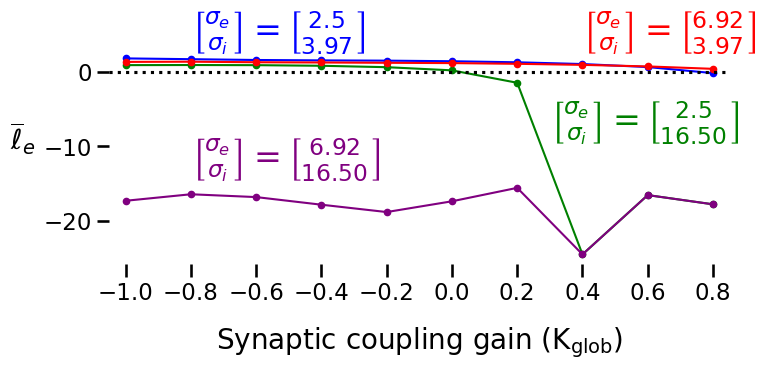

In [7]:
colors= plt.get_cmap('jet')
colorIter = iter(colors(np.linspace(0.3, 1, 4)))

plt.figure(figsize=(8, 2.8))

plt.plot(kVals, Lyap[:, 0], '.-', color = 'b', linewidth=1.5)
plt.text(-0.8, 4, r'$\genfrac{[}{]}{0}{1}{\sigma_e}{\sigma_i} =  \genfrac{[}{]}{0}{1}{2.5}{3.97}$', color = 'b',  fontsize=24)

plt.plot(kVals, Lyap[:, 1], '.-', color = 'g', linewidth=1.5)
plt.text(0.3, -8, r'$\genfrac{[}{]}{0}{1}{\sigma_e}{\sigma_i} =  \genfrac{[}{]}{0}{1}{2.5}{16.50}$', color = 'g',  fontsize=24)

plt.plot(kVals, Lyap[:, 2], '.-', color = 'r', linewidth=1.5)
plt.text(0.4, 4, r'$\genfrac{[}{]}{0}{1}{\sigma_e}{\sigma_i} =  \genfrac{[}{]}{0}{1}{6.92}{3.97}$', color = 'r',  fontsize=24)

plt.plot(kVals, Lyap[:, 3], '.-', color = 'purple', linewidth=1.5)
plt.text(-0.8, -13, r'$\genfrac{[}{]}{0}{1}{\sigma_e}{\sigma_i} = \genfrac{[}{]}{0}{1}{6.92}{16.50}$', color = 'purple',  fontsize=24)

plt.axhline(y=0, color = 'k', linestyle=':')
plt.ylabel(r"$\overline{\ell}_e$", fontsize=20, rotation=0, labelpad=15)
plt.xlabel(r"Synaptic coupling gain $\rm (K_{glob})$", fontsize=20, labelpad=15)
plt.xlim(kMin-0.05, max(kVals)+0.05)
plt.xticks(kVals)

for pos in ["right", "left", "top", "bottom"]:
    plt.gca().spines[pos].set_visible(False)
plt.savefig(os.path.join(figureroot, f"Imod_{iE:.3f}mV_dt_{params['dt']*10}ms_K.png"), dpi=300, bbox_inches='tight')

In [8]:
# Lyap = np.zeros((kSteps, 3))
# sigE = np.zeros((kSteps, 3))
# sigI = np.zeros((kSteps, 3))

# for nf, path_ in enumerate(_sortpaths):
#     if nf == 10:
#         continue

#     lyap_results = pickle.load(open(path_, 'rb'))

#     lyap_results = lyap_results['n1_mean']
#     if len(lyap_results[lyap_results != -np.inf].flatten()) == 0:
#         minValue = -10
#     else:
#         minValue = min(lyap_results[lyap_results != -np.inf])
#     lyap_results[lyap_results == -np.inf] = minValue
    
#     sigE[nf, 0] = seVals[0]; sigI[nf, 0] = siVals[3]; Lyap[nf, 0] = lyap_results[0, 1]
#     sigE[nf, 1] = seVals[7]; sigI[nf, 1] = siVals[3]; Lyap[nf, 1] = lyap_results[7, 1]
#     sigE[nf, 2] = seVals[19]; sigI[nf, 2] = siVals[3]; Lyap[nf, 2] = lyap_results[19, 1]

In [9]:
# colors= plt.get_cmap('jet')
# colorIter = iter(colors(np.linspace(0.3, 1, 4)))

# plt.figure(figsize=(8, 3))

# plt.plot(kVals, Lyap[:, 0], '.-', color = 'b', linewidth=1.5)
# plt.text(-0.9,  1.85, r"$\sigma_e = $" + f"{seVals[0]:.2f}", color = 'b',  fontsize=16)

# plt.plot(kVals, Lyap[:, 1], '.-', color = 'g', linewidth=1.5)
# plt.text(-0.5, 2.3, r"$\sigma_e = $" + f"{seVals[2]:.2f}", color = 'g',  fontsize=16)

# plt.plot(kVals, Lyap[:, 2], '.-', color = 'r', linewidth=1.5)
# plt.text(0.4, 1.8, r"$\sigma_e = $" + f"{seVals[5]:.2f}", color = 'r',  fontsize=16)

# plt.text(0.2, 2.8, r"$\sigma_{\rm i} = $" + f"{siVals[1]:.2f}", color = 'k',  fontsize=24)

# plt.axhline(y=0, color = 'k', linestyle=':')
# plt.ylabel(r"$\overline{\ell}_e$", fontsize=18, rotation=0, labelpad=15)
# plt.xlabel(r"Synaptic Coupling Gain $(K_{\rm glob})$", fontsize=16, labelpad=15)
# plt.xlim(kMin, max(kVals))
# plt.xticks(kVals)
# for pos in ["right", "left", "top", "bottom"]:
#     plt.gca().spines[pos].set_visible(False)
# plt.savefig(os.path.join(figureroot, f"Imod_{iE:.3f}mV_sigi_{siVals[1]:.2f}_K_dt_{params['dt']}ms.png"), dpi=300, bbox_inches='tight')
    

In [10]:
# Lyap = np.zeros((kSteps, 3))
# sigE = np.zeros((kSteps, 3))
# sigI = np.zeros((kSteps, 3))

# for nf, path_ in enumerate(_sortpaths):

#     lyap_results = pickle.load(open(path_, 'rb'))

#     lyap_results = lyap_results['n1_mean']
#     if len(lyap_results[lyap_results != -np.inf].flatten()) == 0:
#         minValue = -10
#     else:
#         minValue = min(lyap_results[lyap_results != -np.inf])
#     lyap_results[lyap_results == -np.inf] = minValue
    
#     sigE[nf, 0] = seVals[0]; sigI[nf, 0] = siVals[-1]; Lyap[nf, 0] = lyap_results[0, -1]
#     sigE[nf, 1] = seVals[7]; sigI[nf, 1] = siVals[-1]; Lyap[nf, 1] = lyap_results[7, -1]
#     sigE[nf, 2] = seVals[19]; sigI[nf, 2] = siVals[-1]; Lyap[nf, 2] = lyap_results[19, -1]

In [11]:
# colors= plt.get_cmap('jet')
# colorIter = iter(colors(np.linspace(0.3, 1, 4)))

# plt.figure(figsize=(8, 3))

# plt.plot(kVals, Lyap[:, 0], '.-', color = 'b', linewidth=1.5)
# plt.text(0.28, -2.5, r"$\sigma_e = $" + f"{seVals[0]:.2f}", color = 'b',  fontsize=16)

# plt.plot(kVals, Lyap[:, 1], '.-', color = 'g', linewidth=1.5)
# plt.text(-0.28, -2.5, r"$\sigma_e = $" + f"{seVals[2]:.2f}", color = 'g',  fontsize=16)

# plt.plot(kVals, Lyap[:, 2], '.-', color = 'r', linewidth=1.5)
# plt.text(-0.9, -8, r"$\sigma_e = $" + f"{seVals[5]:.2f}", color = 'r',  fontsize=16)

# plt.text(0.2, 3.4, r"$\sigma_{\rm i} = $" + f"{siVals[-1]:.2f}", color = 'k',  fontsize=24)

# plt.axhline(y=0, color = 'k', linestyle=':')
# plt.ylabel(r"$\overline{\ell}_e$", fontsize=18, rotation=0, labelpad=15)
# plt.xlabel(r"Synaptic Coupling Gain $(K_{\rm glob})$", fontsize=16, labelpad=15)
# plt.xlim(kMin, max(kVals))
# plt.xticks(kVals)
# for pos in ["right", "left", "top", "bottom"]:
#     plt.gca().spines[pos].set_visible(False)
# plt.savefig(os.path.join(figureroot, f"Imod_{iE:.3f}mV_sigi_{siVals[-1]:.2f}_K_dt_{params['dt']}ms.png"), dpi=300, bbox_inches='tight')
    

In [12]:
K = -0.2

seMin = 2.5; seMax = 16.5; seSteps = 20
seVals = seMin + np.arange(0, seSteps) / (seSteps - 1) * (seMax - seMin)

siMin = 2.5; siMax = 16.5; siSteps = 20
siVals = siMin + np.arange(0, siSteps) / (siSteps - 1) * (siMax - siMin)

In [13]:
_temp = []
_sortpaths = []

for path_ in file_paths:
    if f"K_{K:.2f}" not in path_:
        continue
    Basename = os.path.basename(path_).split('.pkl')[0]
    I = float(Basename.split('_ie_')[-1])
    _temp.append(I)
    _sortpaths.append(path_)

_temp = np.array(_temp)
Isort = np.argsort(_temp)

_sortpaths = np.array(_sortpaths)
_sortpaths = _sortpaths[Isort]
iVals = _temp[Isort]
iVals -= params['i_e2']

In [14]:
Lyap = np.zeros((len(_temp), 4))
sigE = np.zeros((len(_temp), 4))
sigI = np.zeros((len(_temp), 4))

for nf, path_ in enumerate(_sortpaths):

    lyap_results = pickle.load(open(path_, 'rb'))

    # lyap_results = lyap_results['n1_mean']

    if len(lyap_results[lyap_results != -np.inf].flatten()) == 0:
        minValue = -15
    else:
        minValue = min(lyap_results[lyap_results != -np.inf])

    lyap_results[lyap_results == -np.inf] = minValue
    
    sigE[nf, 0] = seVals[0]; sigI[nf, 0] = siVals[2]; Lyap[nf, 0] = lyap_results[0, 2]
    sigE[nf, 1] = seVals[0]; sigI[nf, 1] = siVals[-1]; Lyap[nf, 1] = lyap_results[0, -1]
    sigE[nf, 2] = seVals[6]; sigI[nf, 2] = siVals[2]; Lyap[nf, 2] = lyap_results[6, 2]
    sigE[nf, 3] = seVals[6]; sigI[nf, 3] = siVals[-1]; Lyap[nf, 3] = lyap_results[6, -1]

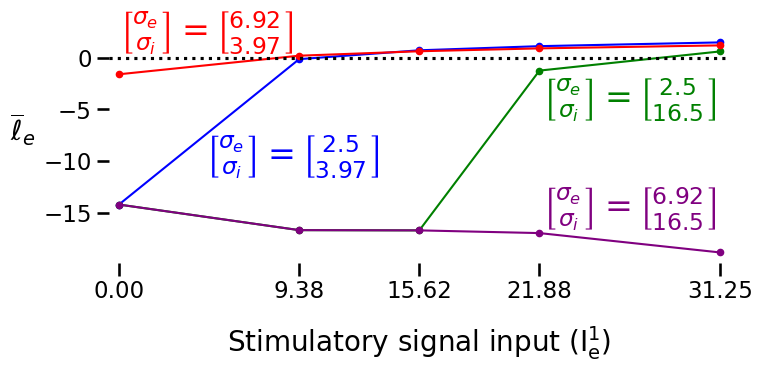

In [15]:
colors= plt.get_cmap('jet')
colorIter = iter(colors(np.linspace(0.3, 1, 4)))

plt.figure(figsize=(8, 3))

plt.plot(iVals, Lyap[:, 0], '.-', color = 'b', linewidth=1.5)
plt.text(4.5, -10.5, r'$\genfrac{[}{]}{0}{1}{\sigma_e}{\sigma_i} =  \genfrac{[}{]}{0}{1}{2.5}{3.97}$', color = 'b',  fontsize=24)

plt.plot(iVals, Lyap[:, 1], '.-', color = 'g', linewidth=1.5)
plt.text(22., -5, r'$\genfrac{[}{]}{0}{1}{\sigma_e}{\sigma_i} =  \genfrac{[}{]}{0}{1}{2.5}{16.5}$', color = 'g',  fontsize=24)

plt.plot(iVals, Lyap[:, 2], '.-', color = 'r', linewidth=1.5)
plt.text(0, 1.5, r'$\genfrac{[}{]}{0}{1}{\sigma_e}{\sigma_i} =  \genfrac{[}{]}{0}{1}{6.92}{3.97}$', color = 'r',  fontsize=24)

plt.plot(iVals, Lyap[:, 3], '.-', color = 'purple', linewidth=1.5)
plt.text(22, -15.5, r'$\genfrac{[}{]}{0}{1}{\sigma_e}{\sigma_i} = \genfrac{[}{]}{0}{1}{6.92}{16.5}$', color = 'purple',  fontsize=24)

plt.axhline(y=0, color = 'k', linestyle=':')
plt.ylabel(r"$\overline{\ell}_e$", fontsize=20, rotation=0, labelpad=15)
plt.xlabel(r"Stimulatory signal input $(\rm I^1_e)$", fontsize=20, labelpad=15)
plt.xlim(min(iVals)-0.5, max(iVals)+0.5)
plt.xticks(iVals)
for pos in ["right", "left", "top", "bottom"]:
    plt.gca().spines[pos].set_visible(False)
# plt.savefig(os.path.join(figureroot, f"K_{K:.2f}_Imod.png"), dpi=300, bbox_inches='tight')

In [16]:
# Lyap = np.zeros((len(_temp), 3))
# sigE = np.zeros((len(_temp), 3))
# sigI = np.zeros((len(_temp), 3))

# for nf, path_ in enumerate(_sortpaths):

#     lyap_results = pickle.load(open(path_, 'rb'))

#     lyap_results = lyap_results['n1_mean']

#     if len(lyap_results[lyap_results != -np.inf].flatten()) == 0:
#         minValue = -15
#     else:
#         minValue = min(lyap_results[lyap_results != -np.inf])

#     lyap_results[lyap_results == -np.inf] = minValue

#     sigE[nf, 0] = seVals[0]; sigI[nf, 0] = siVals[3]; Lyap[nf, 0] = lyap_results[0, 1]
#     sigE[nf, 1] = seVals[7]; sigI[nf, 1] = siVals[3]; Lyap[nf, 1] = lyap_results[7, 1]
#     sigE[nf, 2] = seVals[19]; sigI[nf, 2] = siVals[3]; Lyap[nf, 2] = lyap_results[19, 1]

In [17]:
# colors= plt.get_cmap('jet')
# colorIter = iter(colors(np.linspace(0.3, 1, 4)))

# plt.figure(figsize=(8, 3))

# plt.plot(iVals, Lyap[:, 0], '.-', color = 'b', linewidth=1.5)
# plt.text(14,  -5, r"$\sigma_e = $" + f"{seVals[0]:.2f}", color = 'b',  fontsize=16)

# plt.plot(iVals, Lyap[:, 1], '.-', color = 'g', linewidth=1.5)
# plt.text(4, -4, r"$\sigma_e = $" + f"{seVals[7]:.2f}", color = 'g',  fontsize=16)

# plt.plot(iVals, Lyap[:, 2], '.-', color = 'r', linewidth=1.5)
# plt.text(0.4, 1.8, r"$\sigma_e = $" + f"{seVals[19]:.2f}", color = 'r',  fontsize=16)

# plt.text(22, 4, r"$\sigma_i = $" + f"{siVals[1]:.2f}", color = 'k',  fontsize=24)

# plt.axhline(y=0, color = 'k', linestyle=':')
# plt.ylabel(r"$\overline{\ell}_e$", fontsize=18, rotation=0, labelpad=15)
# plt.xlabel(r"Modulatory signal input $(I^1_{\rm e})$", fontsize=16, labelpad=15)
# plt.xlim(min(iVals), max(iVals))
# plt.xticks(iVals)
# for pos in ["right", "left", "top", "bottom"]:
#     plt.gca().spines[pos].set_visible(False)
# plt.savefig(os.path.join(figureroot, f"K_{K:.2f}_sigi_{siVals[1]:.2f}_Imod_dt_{params['dt']}ms.png"), dpi=300, bbox_inches='tight')
    

In [18]:
# Lyap = np.zeros((len(_temp), 3))
# sigE = np.zeros((len(_temp), 3))
# sigI = np.zeros((len(_temp), 3))

# for nf, path_ in enumerate(_sortpaths):

#     lyap_results = pickle.load(open(path_, 'rb'))

#     lyap_results = lyap_results['n1_mean']

#     if len(lyap_results[lyap_results != -np.inf].flatten()) == 0:
#         minValue = -15
#     else:
#         minValue = min(lyap_results[lyap_results != -np.inf])

#     lyap_results[lyap_results == -np.inf] = minValue

#     sigE[nf, 0] = seVals[0]; sigI[nf, 0] = siVals[3]; Lyap[nf, 0] = lyap_results[0, -1]
#     sigE[nf, 1] = seVals[7]; sigI[nf, 1] = siVals[3]; Lyap[nf, 1] = lyap_results[7, -1]
#     sigE[nf, 2] = seVals[19]; sigI[nf, 2] = siVals[3]; Lyap[nf, 2] = lyap_results[19, -1]

In [19]:
# colors= plt.get_cmap('jet')
# colorIter = iter(colors(np.linspace(0.3, 1, 4)))

# plt.figure(figsize=(8, 3))

# plt.plot(iVals, Lyap[:, 0], '.-', color = 'b', linewidth=1.5)
# plt.text(22,  -4, r"$\sigma_e = $" + f"{seVals[0]:.2f}", color = 'b',  fontsize=16)

# plt.plot(iVals, Lyap[:, 1], '.-', color = 'g', linewidth=1.5)
# plt.text(9, -13, r"$\sigma_e = $" + f"{seVals[7]:.2f}", color = 'g',  fontsize=16)

# plt.plot(iVals, Lyap[:, 2], '.-', color = 'r', linewidth=1.5)
# plt.text(0.4, -5, r"$\sigma_e = $" + f"{seVals[19]:.2f}", color = 'r',  fontsize=16)

# plt.text(22, 4, r"$\sigma_i = $" + f"{siVals[-1]:.2f}", color = 'k',  fontsize=24)

# plt.axhline(y=0, color = 'k', linestyle=':')
# plt.ylabel(r"$\overline{\ell}_e$", fontsize=18, rotation=0, labelpad=15)
# plt.xlabel(r"Modulatory signal input $(I^1_{\rm e})$", fontsize=16, labelpad=15)
# plt.xlim(min(iVals), max(iVals))
# plt.xticks(iVals)
# for pos in ["right", "left", "top", "bottom"]:
#     plt.gca().spines[pos].set_visible(False)
# plt.savefig(os.path.join(figureroot, f"K_{K:.2f}_sigi_{siVals[-1]:.2f}_Imod_dt_{params['dt']}ms.png"), dpi=300, bbox_inches='tight')
    

#### State transition boundary detection

In [20]:
# setting the variables
k_values = np.arange(-1, 1, 0.2)
iPert = [0.  , 0.15, 0.25, 0.35, 0.5] 

sige_min = 2.5; sige_max = 16.5; sige_steps = 20
sigi_min = 2.5; sigi_max = 16.5; sigi_steps = 20

eval_sigma_e = sige_min + np.arange(0, sige_steps) / (sige_steps - 1) * (sige_max - sige_min)
eval_sigma_i = sigi_min + np.arange(0, sigi_steps) / (sigi_steps - 1) * (sigi_max - sigi_min)

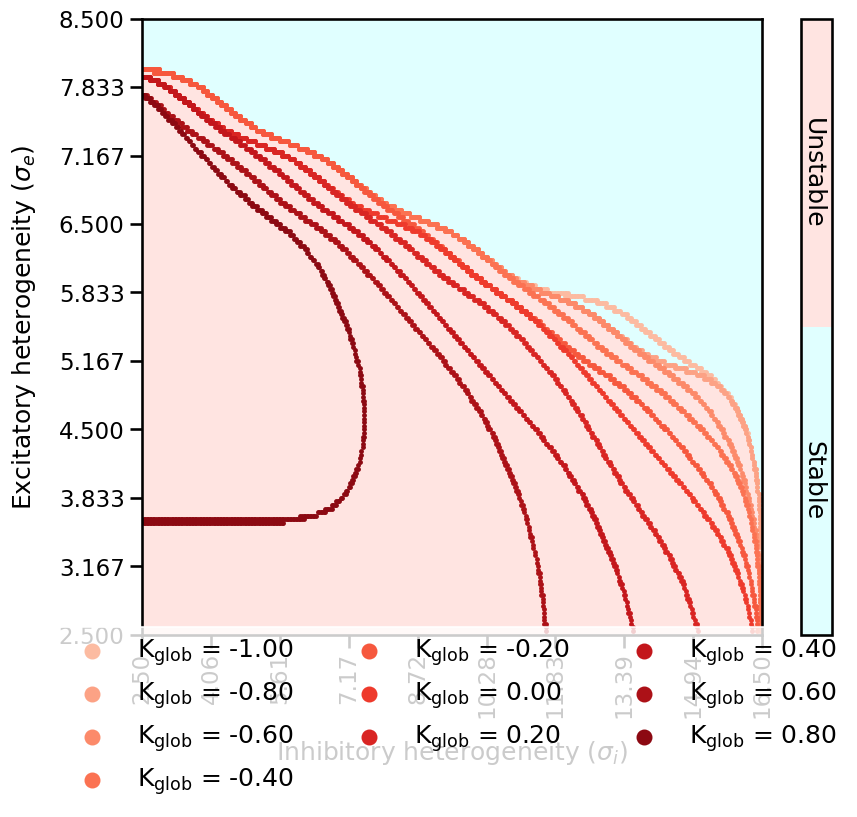

In [24]:
# %%capture
from scipy.ndimage import gaussian_filter1d

save_str = datetime.datetime(2025, 1, 15)
results_dict = os.path.join('../system_02/results/lyapunov_numba/', f"exp-{save_str.year}-{save_str.month}-{save_str.day}")

for nI, I in enumerate(iPert):
    if I != 0.5:
        continue
    file_paths = glob.glob(os.path.join(results_dict, f"*_ie_{I / params['gamma'] + params['i_e2']:.3f}.pkl"))
    num_files = len(file_paths)

    K_vals = []

    if num_files == 0:
        print('no files found!')

    else:
        for nf, path in enumerate(file_paths):
            basename = os.path.basename(path).split('.pkl')[0]
            K = float(basename.split('K_')[-1].split('_ie')[0])

            if K == -0.00:
                K = 0.0
            K_vals.append(K)
        
        K_vals = np.array(K_vals)

        order_ind = np.argsort(K_vals)
        K_vals = K_vals[order_ind]
        file_paths = np.array(file_paths)[order_ind]

        colors= plt.get_cmap('Reds')
        colorIter = iter(colors(np.linspace(0.25, 1, len(K_vals))))

        last_response = None
        ifPlot = True
        plt.figure(figsize=(10,8))
            
        for nf, path in enumerate(file_paths):
            if K_vals[nf] == -0.8:
                lyap_results = pickle.load(open(path, 'rb'))
                lyap_results = lyap_results['n1_mean'] if type(lyap_results) == dict else lyap_results

                # orig_response = lyapunov_threshold(lyap_results['n1_mean'], 0.001)
                orig_response = lyapunov_threshold(lyap_results, 0.001)

                sige_arr, sigi_arr, response_map = lyapunov_upsample(
                                                                    orig_response=orig_response, 
                                                                    eval_arrx=eval_sigma_i, 
                                                                    eval_arry=eval_sigma_e, 
                                                                    y_min = sige_min, y_max = len(eval_sigma_e), 
                                                                    x_min = sigi_min, x_max = len(eval_sigma_i), 
                                                                    sigma_x = 25, sigma_y = 25,  
                                                                    resolution = 500
                                                                )
                heatmap = plt.pcolormesh(sigi_arr, sige_arr, response_map, cmap=ListedColormap(['lightcyan', 'mistyrose']))
                cbar = plt.colorbar(heatmap)

                cbar.ax.get_yaxis().set_ticks([])
                cbar.ax.text(0.4, .5 , r"Unstable", rotation=270, ha='center', va='center', fontsize=18)
                cbar.ax.text(0.4, -0.5 , r"Stable", rotation=270, ha='center', va='center', fontsize=18)

        for nf, path in enumerate(file_paths):
            basename = os.path.basename(path).split('.pkl')[0]
            I = float(basename.split('ie_')[-1])
            color = next(colorIter)
            
            lyap_results = pickle.load(open(path, 'rb'))
            lyap_results = lyap_results['n1_mean'] if type(lyap_results) == dict else lyap_results

            # orig_response = lyapunov_threshold(lyap_results['n1_mean'], 0.001)
            orig_response = lyapunov_threshold(lyap_results, 0.001)

            sige_arr, sigi_arr, response_map = lyapunov_upsample(
                                                                    orig_response=orig_response, 
                                                                    eval_arrx=eval_sigma_i, 
                                                                    eval_arry=eval_sigma_e, 
                                                                    y_min = sige_min, y_max = len(eval_sigma_e), 
                                                                    x_min = sigi_min, x_max = len(eval_sigma_i), 
                                                                    sigma_x = 25, sigma_y = 25,  
                                                                    resolution = 500
                                                                )
            
            edge_boundary, sigi_edges, sige_edges = boundary_detection(response_map, sige_arr, sigi_arr)

                
            if not edge_boundary:
                continue

            plot_x = np.linspace(min(sigi_edges), max(sigi_edges), 1000)
            plot_y = edge_boundary(plot_x)

            sige_edges_gaus = gaussian_filter1d(sige_edges, 5) if K_vals[nf] != 0.8 else sige_edges
            plt.scatter(sigi_edges, sige_edges, marker='.', s = 16, c = color,  label = r"$\rm K_{glob}$" + f" = {K_vals[nf]:.2f}")
            # plt.scatter(sigi_edges, sige_edges_gaus, marker='.', s = 16, c = color)

        
        # plt.axhline(y = 2.5, linestyle=":", color="b"); plt.axhline(y = 9.87, linestyle=":", color="b")
        # plt.axvline(x = 3.97, linestyle=":", color="k"); plt.axvline(x = 16.5, linestyle=":", color="k")
        plt.xlabel(r"Inhibitory heterogeneity $(\sigma_i)$", labelpad=15); plt.ylabel(r"Excitatory heterogeneity $(\sigma_e)$", labelpad=15)
        plt.xticks(np.linspace(2.5, 16.5, 10), rotation = 90); plt.yticks(np.linspace(2.5, 8.5, 10))
        plt.xlim(2.5, 16.5); plt.ylim(2.5, 8.5)
        # plt.title(r"$I^1_e = $" + f"{I - params['i_e2']:.3f}mV")
        plt.legend(loc = 'lower center', bbox_to_anchor=(0.5, -0.3), edgecolor="white", ncols=3, markerscale=5, fontsize=18)
        plt.savefig(os.path.join(figureroot, f"boundarydetection_modulation_Imod_{I - params['i_e2']:.3f}mV_dt_{params['dt']}ms.png"), dpi = 300, bbox_inches='tight')
        plt.show()

In [285]:
# setting grid parameters
minval = -5 / params['gamma']
maxval = 5 / params['gamma']
grid_res = 100
n_trials = 10

# time vector
T = params['T'] = 10000
time_ = np.arange(0, T)

# setting init values
np.random.seed(0)
x0_ = np.random.uniform(minval, maxval, n_trials)
x1_ = np.random.uniform(minval, maxval, n_trials)
x2_ = np.random.uniform(minval, maxval, n_trials)
x3_ = np.random.uniform(minval, maxval, n_trials)

t_start = 1000
t_end = params['T']

In [286]:
def plot_trajectory(ts, init_points, fig_size=(10, 10)):
    dim_labels = [r'$u_{\rm e}^1$', r'$u_{\rm i}^1$', r'$u_{\rm e}^2$', r'$u_{\rm i}^2$']
    plt_grads = False

    fig, axes = plt.subplots(1, 4, figsize=fig_size)

    # Plotting the vector field in the state space (E, I)
    axes[0].set_ylabel(dim_labels[0], rotation=0, labelpad=15, fontsize=28);
    axes[0].set_xlabel(dim_labels[1], fontsize=28)
    axes[0].grid(True)

    axes[1].set_ylabel(dim_labels[2], rotation=0, labelpad=15, fontsize=28);
    axes[1].set_xlabel(dim_labels[3], fontsize=28)
    axes[1].grid(True)

    axes[2].set_ylabel(dim_labels[0], rotation=0, labelpad=15, fontsize=28);
    axes[2].set_xlabel(dim_labels[2], fontsize=28)
    axes[2].grid(True)

    axes[3].set_ylabel(f"{dim_labels[2]} - {dim_labels[0]}", labelpad=15, fontsize=28);
    axes[3].set_xlabel(f"{dim_labels[3]} - {dim_labels[1]}", fontsize=28)
    axes[3].grid(True)

    x0_, x1_, x2_, x3_ = init_points

    for k, y0 in enumerate(zip(x0_, x1_, x2_, x3_)):
        kts = ts[k, :, :]
        # xdim0, xdim1 = xSolve[plot_dim]

        # Plot the solution in the state space
        axes[0].plot(kts[1, :], kts[0, :], 'b-')
        axes[0].scatter(y0[1], y0[0], marker='.', c='k', s=200, label=f"{dim_labels[0]} = {y0[0]:.3f}, {dim_labels[1]} = {y0[1]:.3f}")

        axes[1].plot(kts[3, :], kts[2, :], 'b-')
        axes[1].scatter(y0[3], y0[2], marker='.', c='k', s=200,
                           label=f"{dim_labels[2]} = {y0[2]:.3f}, {dim_labels[3]} = {y0[3]:.3f}")

        axes[2].plot(kts[2, :], kts[0, :], 'b-')
        axes[2].scatter(y0[2], y0[0], marker='.', c='k', s=200,
                           label=f"{dim_labels[0]} = {y0[0]:.3f}, {dim_labels[2]} = {y0[2]:.3f}")

        axes[3].plot(kts[3, :] - kts[1, :], kts[2, :] - kts[0, :], 'b-')
        axes[3].scatter(y0[3] - y0[1], y0[2] - y0[0], marker='.', c='k', s=200,
                           label=f"{dim_labels[2]} - {dim_labels[0]} = {y0[2] - y0[0]:.3f}, {dim_labels[3]} - {dim_labels[1]} = {y0[3] - y0[1]:.3f}")
        break

    for pos in ['right', 'top', 'bottom', 'left']:
        axes[0].spines[pos].set_visible(False)
        axes[1].spines[pos].set_visible(False)
        axes[2].spines[pos].set_visible(False)
        axes[3].spines[pos].set_visible(False)

    # axes[0, 1].tick_params(axis='y', which='both', labelleft=False, labelright=True)
    # axes[1, 1].tick_params(axis='y', which='both', labelleft=False, labelright=True)
    fig.align_ylabels()
    fig.tight_layout()
    plt.show()
    return

In [ ]:
seVals

In [288]:
def standarize_series(unstd_series):
    std_ = np.std(unstd_series)
    mean_ = np.mean(unstd_series)

    if round(std_ / mean_, 2) == 0:
        norm_series = unstd_series - mean_
    
    else:
        norm_series = (unstd_series - mean_) / std_

    return norm_series

In [289]:
def event_detection(ue_series, zlimit=1.65, t2=t_end, t1=t_start):
    t_max_events = []
    t_min_events = []

    for t in range(0, t2 - t1):
        if ue_series[t] <= -zlimit:
            t_min_events.append(t)

        if ue_series[t] >= zlimit:
            t_max_events.append(t)

    return np.array(t_max_events), np.array(t_min_events)

def remove_spurious(tseries):
    trueEvent_mask = np.where(np.diff(tseries) > 1)[0]
    tseries = tseries[trueEvent_mask]

    return tseries

In [422]:
params['i_e1'] = 0.5 / params['gamma'] + params['i_e2']
params['sig_e1'] = params['sig_e2'] = 9.13157895
params['sig_i1'] = params['sig_i2'] = 9.13157895
params['K'] = 0

In [423]:
u = np.zeros((n_trials, 4, T))
u = euler_intergrate(u, [x0_, x1_, x2_, x3_], **params)

In [424]:
ue1 = np.mean(u[:, 0, t_start:], axis=0)
ue2 = np.mean(u[:, 2, t_start:], axis=0)

lyapunov_1 = np.zeros((T - t_start - 1))
for k in range(n_trials):
    diff_1 = np.abs(np.diff(u[k, 0, t_start:]))
    lyapunov_1 += 1 / n_trials * np.log(diff_1)
if np.mean(lyapunov_1) == -np.inf:
    lyapunov_1 = -10
cv = 0
for k in range(n_trials):
    cv_ = np.std(u[k, 0, t_start:]) / np.mean(u[k, 0, t_start:]) + np.std(u[k, 2, t_start:]) / np.mean(u[k, 2, t_start:])
    cv_ = cv_ / 2
    cv += 1 / n_trials * cv_

In [425]:
ue1 = np.mean(u[:, 0, t_start:], axis=0)
ue2 = np.mean(u[:, 2, t_start:], axis=0)

ui1 = np.mean(u[:, 1, t_start:], axis=0)
ui2 = np.mean(u[:, 3, t_start:], axis=0)

In [426]:
ue1_std = standarize_series(unstd_series=ue1)
ue2_std = standarize_series(unstd_series=ue2)

In [427]:
t1_max, t1_min = event_detection(ue1_std)
t1_max = remove_spurious(t1_max)
t1_min = remove_spurious(t1_min)

t2_max, t2_min = event_detection(ue2_std)
t2_max = remove_spurious(t2_max)
t2_min = remove_spurious(t2_min)

In [428]:
t1_events = np.zeros_like(ue1_std)

if len(t1_max) > 0:
    t1_events[t1_max] = 1
if len(t1_min) > 0:
    t1_events[t1_min] = -1

t2_events = np.zeros_like(ue2_std)

if len(t2_max) > 0:
    t2_events[t2_max] = 1
if len(t2_min) > 0:
    t2_events[t2_min] = -1

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 5), sharex=True)
axes[0, 0].plot(time_[:-t_start], ue1_std, color='r')
axes[0, 0].axhline(y=1.65, color='k', linestyle=':')
axes[0, 0].axhline(y=-1.65, color='k', linestyle=':')
axes[0, 0].set_ylabel(r'$u_{\rm z}^{1}$', rotation=0, labelpad=25, fontsize=18)

for pos in ["right", "left", "top"]:
    axes[0, 0].spines[pos].set_visible(False)
    axes[1, 0].spines[pos].set_visible(False)
    axes[0, 1].spines[pos].set_visible(False)
    axes[1, 1].spines[pos].set_visible(False)

axes[1, 0].plot(time_[:-t_start], ue2_std, color='r')
axes[1, 0].axhline(y=1.65, color='k', linestyle=':')
axes[1, 0].axhline(y=-1.65, color='k', linestyle=':')
axes[1, 0].set_ylabel(r'$u_{\rm z}^{2}$', rotation=0, labelpad=25, fontsize=18)
axes[1, 0].set_xlabel('Time (a.u.)', fontsize=18)
axes[1, 0].set_xlim(0, 9000)


if len(t1_max) > 0:
    (markerline, stemlines, baseline) = axes[0, 1].stem(t1_max, np.ones_like(t1_max))
    plt.setp(stemlines, linewidth=1.2, color='k')
    plt.setp(markerline, markersize = 5, color='b')
else:
    (markerline, stemlines, baseline) = axes[0, 1].stem(time_[:-t_start], np.zeros_like(time_[:-t_start]))
    plt.setp(markerline, visible=False)
    plt.setp(stemlines, visible=False)

if len(t1_min) > 0:
    (markerline, stemlines, baseline) = axes[0, 1].stem(t1_min, -np.ones_like(t1_min))
    plt.setp(stemlines, linewidth=1.2, color='k')
    plt.setp(markerline, markersize = 5, color='b')
else:
    (markerline, stemlines, baseline) = axes[0, 1].stem(time_[:-t_start], np.zeros_like(time_[:-t_start]))
    plt.setp(markerline, visible=False)
    plt.setp(stemlines, visible=False)


if len(t2_max) > 0:
    (markerline, stemlines, baseline) = axes[1, 1].stem(t2_max, np.ones_like(t2_max))
    plt.setp(stemlines, linewidth=1.2, color='k')
    plt.setp(markerline, markersize = 5, color='b')
else:
    (markerline, stemlines, baseline) = axes[1, 1].stem(time_[:-t_start], np.zeros_like(time_[:-t_start]))
    plt.setp(markerline, visible=False)
    plt.setp(stemlines, visible=False)


if len(t2_min) > 0:
    (markerline, stemlines, baseline) = axes[1, 1].stem(t2_min, -np.ones_like(t2_min))
    plt.setp(stemlines, linewidth=1.2, color='k')
    plt.setp(markerline, markersize = 5, color='b')
else:
    (markerline, stemlines, baseline) = axes[1, 1].stem(time_[:-t_start], np.zeros_like(time_[:-t_start]))
    plt.setp(markerline, visible=False)
    plt.setp(stemlines, visible=False)


axes[1, 1].set_xlabel('Event points', fontsize=18)
axes[1, 1].set_xlim(0, 9000)
axes[0, 1].set_ylim(-1.1, 1.1)
axes[1, 1].set_ylim(-1.1, 1.1)


fig.align_ylabels()

In [ ]:
fig = plt.figure(figsize=(12, 5))
plt.subplot(2, 1, 1)
plt.plot(time_[:-t_start], ue1, color='r')
plt.ylabel(r'$u_{\rm e}^{1}$', rotation=0, labelpad=25, fontsize=18)
plt.xlabel('Time (a.u.)', fontsize=18)
plt.xlim(1000, 3000)

for pos in ["right", "left", "top"]:
    plt.gca().spines[pos].set_visible(False)

plt.subplot(2, 1, 2)
plt.plot(time_[:-t_start], ue2, color='r')
plt.ylabel(r'$u_{\rm e}^{2}$', rotation=0, labelpad=25, fontsize=18)
plt.xlabel('Time (a.u.)', fontsize=18)
plt.xlim(1000, 3000)

for pos in ["right", "left", "top"]:
    plt.gca().spines[pos].set_visible(False)

fig.align_labels()
plt.tight_layout()

In [ ]:
fig = plt.figure(figsize=(12, 5))
plt.subplot(2, 1, 1)
plt.plot(time_[:-t_start], ue1, color='r')
plt.plot(time_[:-t_start], ue2, color='k')
plt.ylabel(r'$u_{\rm e}^{1,2}$', rotation=0, labelpad=25, fontsize=18)
plt.xlabel('Time (a.u.)', fontsize=18)
plt.xlim(0, 9000)
plt.text(500, np.max(ue1) + 4, r"$\overline{\ell}_e$ = " + f"{np.mean(lyapunov_1):.3f}", fontsize=18)
plt.text(3500, np.max(ue1) + 4, r"CV = " + f"{abs(cv):.3f}", fontsize=18)
# plt.text(7000, np.max(ue1) + 4, r"$CV$ = " + f"{abs(cv):.3f}", fontsize=32)

for pos in ["right", "left", "top"]:
    plt.gca().spines[pos].set_visible(False)

plt.subplot(2, 1, 2)
plt.plot(time_[:-t_start], ui1, color='r')
plt.plot(time_[:-t_start], ui2, color='k')
plt.ylabel(r'$u_{\rm i}^{1,2}$', rotation=0, labelpad=25, fontsize=18)
plt.xlabel('Time (a.u.)', fontsize=18)
plt.xlim(0, 9000)

for pos in ["right", "left", "top"]:
    plt.gca().spines[pos].set_visible(False)

fig.align_labels()
plt.tight_layout()

In [ ]:
plot_trajectory(ts=u, init_points=[x0_, x1_, x2_, x3_], fig_size=(20, 5))